# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** Sohan  
**`Roll Number`:** U20230162  
**`GitHub Branch`:** sohan_U20230162  

# Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from rlcmab_sampler import sampler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load Datasets

In [2]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("=== DATASET OVERVIEW ===")
print(f"\nNews Articles: {news_df.shape[0]} articles, {news_df.shape[1]} features")
print(f"Train Users: {train_users.shape[0]} users, {train_users.shape[1]} features")
print(f"Test Users: {test_users.shape[0]} users, {test_users.shape[1]} features")

print("\n=== News Categories ===")
print(news_df['category'].value_counts())

print("\n=== User Labels ===")
print(train_users['label'].value_counts())

=== DATASET OVERVIEW ===

News Articles: 209527 articles, 6 features
Train Users: 2000 users, 33 features
Test Users: 2000 users, 32 features

=== News Categories ===
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY   

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [4]:
# Data Preprocessing
print("=== DATA PREPROCESSING ===")

# Handle missing values in train_users
print(f"\nMissing values in train_users:\n{train_users.isnull().sum()}")
train_users_clean = train_users.dropna(subset=['label'])  # Remove rows with missing labels
train_users_clean = train_users_clean.fillna(train_users_clean.mean(numeric_only=True))

print(f"\nMissing values in test_users:\n{test_users.isnull().sum()}")
test_users_clean = test_users.fillna(test_users.mean(numeric_only=True))

# Separate features and labels
X_train = train_users_clean.drop('label', axis=1)
y_train = train_users_clean['label']

# Encode categorical features
le_dict = {}
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    le_dict[col] = le

# Apply same encoding to test_users - handle unknown values
X_test = test_users_clean.copy()
for col in categorical_cols:
    if col in le_dict:
        # Handle unknown values by assigning them a default value (0)
        X_test[col] = X_test[col].astype(str)
        known_values = set(le_dict[col].classes_)
        X_test[col] = X_test[col].apply(
            lambda x: le_dict[col].transform([x])[0] if x in known_values else 0
        )

# Encode target labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
label_map = {i: label for i, label in enumerate(label_encoder.classes_)}

print(f"\nLabel Mapping: {label_map}")
print(f"\nPreprocessed data shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

=== DATA PREPROCESSING ===

Missing values in train_users:
user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment_count           0
browser_version                

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [5]:
# Split data for user classification
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train_encoded, test_size=0.2, random_state=42, stratify=y_train_encoded
)

print("=== USER CLASSIFICATION MODEL ===")
print(f"Training set size: {X_train_split.shape[0]} ({80}%)")
print(f"Validation set size: {X_val_split.shape[0]} ({20}%)")

# Train Random Forest Classifier
user_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
user_classifier.fit(X_train_split, y_train_split)

# Evaluate on validation set
y_pred_val = user_classifier.predict(X_val_split)
val_accuracy = accuracy_score(y_val_split, y_pred_val)

print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print("\n=== Classification Report (Validation Set) ===")
print(classification_report(y_val_split, y_pred_val, target_names=label_encoder.classes_))

# Predict on test set
test_user_predictions = user_classifier.predict(X_test)
test_user_contexts = np.array([label_encoder.classes_[pred] for pred in test_user_predictions])

print(f"\nTest Set Predictions:")
print(f"User1: {np.sum(test_user_predictions == 0)}")
print(f"User2: {np.sum(test_user_predictions == 1)}")
print(f"User3: {np.sum(test_user_predictions == 2)}")

=== USER CLASSIFICATION MODEL ===
Training set size: 1600 (80%)
Validation set size: 400 (20%)

Validation Accuracy: 0.9000

=== Classification Report (Validation Set) ===
              precision    recall  f1-score   support

      user_1       0.89      0.86      0.87       142
      user_2       0.97      0.89      0.93       142
      user_3       0.84      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400


Test Set Predictions:
User1: 720
User2: 760
User3: 520


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [6]:
# Initialize the sampler with roll number
ROLL_NUMBER = 162  # From U20230162
reward_sampler = sampler(ROLL_NUMBER)

print(f"Reward Sampler initialized with Roll Number: {ROLL_NUMBER}")

# Get news categories and create arm mapping
news_categories = ['Entertainment', 'Education', 'Tech', 'Crime']
user_contexts = ['user_1', 'user_2', 'user_3']

# Create arm mapping: j = context_index * 4 + category_index
def get_arm_index(context, category):
    """Convert (context, category) to arm index j"""
    context_map = {'user_1': 0, 'user_2': 1, 'user_3': 2}
    category_map = {'Entertainment': 0, 'Education': 1, 'Tech': 2, 'Crime': 3}
    return context_map[context] * 4 + category_map[category]

def get_context_category_from_arm(j):
    """Convert arm index j to (context, category)"""
    context_idx = j // 4
    category_idx = j % 4
    return user_contexts[context_idx], news_categories[category_idx]

# Print arm mapping
print("\n=== ARM INDEX MAPPING ===")
for j in range(12):
    context, category = get_context_category_from_arm(j)
    print(f"Arm {j:2d}: ({category:12s}, {context})")

Reward Sampler initialized with Roll Number: 162

=== ARM INDEX MAPPING ===
Arm  0: (Entertainment, user_1)
Arm  1: (Education   , user_1)
Arm  2: (Tech        , user_1)
Arm  3: (Crime       , user_1)
Arm  4: (Entertainment, user_2)
Arm  5: (Education   , user_2)
Arm  6: (Tech        , user_2)
Arm  7: (Crime       , user_2)
Arm  8: (Entertainment, user_3)
Arm  9: (Education   , user_3)
Arm 10: (Tech        , user_3)
Arm 11: (Crime       , user_3)


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [7]:
print("=== EPSILON-GREEDY ALGORITHM ===\n")

class EpsilonGreedyBandit:
    def __init__(self, n_arms, epsilon):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.Q = np.zeros(n_arms)  # Estimated values
        self.N = np.zeros(n_arms)  # Number of times each arm was selected
        self.rewards = []
    
    def select_arm(self):
        """Select arm using epsilon-greedy policy"""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_arms)
        else:
            return np.argmax(self.Q)
    
    def update(self, arm, reward):
        """Update Q-values with new reward"""
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]
        self.rewards.append(reward)
    
    def run(self, n_steps, sampler_func):
        """Run the bandit for n_steps"""
        for step in range(n_steps):
            arm = self.select_arm()
            reward = sampler_func(arm)
            self.update(arm, reward)
        return np.array(self.rewards)

# Test different epsilon values
epsilon_values = [0.01, 0.1, 0.3]
T = 10000

print(f"Running simulations for T={T} steps with epsilon values: {epsilon_values}\n")

eg_results = {}
for eps in epsilon_values:
    print(f"Epsilon = {eps}...", end='', flush=True)
    bandit = EpsilonGreedyBandit(n_arms=12, epsilon=eps)
    rewards = bandit.run(T, reward_sampler.sample)
    eg_results[eps] = {
        'rewards': rewards,
        'Q_values': bandit.Q.copy(),
        'N_values': bandit.N.copy()
    }
    print(f" Done! Avg Reward: {np.mean(rewards):.4f}")

print("\n" + "="*60)

=== EPSILON-GREEDY ALGORITHM ===

Running simulations for T=10000 steps with epsilon values: [0.01, 0.1, 0.3]

Epsilon = 0.01... Done! Avg Reward: 8.0218
Epsilon = 0.1... Done! Avg Reward: 7.6760
Epsilon = 0.3... Done! Avg Reward: 6.1314



## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [8]:
print("=== UPPER CONFIDENCE BOUND (UCB) ALGORITHM ===\n")

class UCBBandit:
    def __init__(self, n_arms, C):
        self.n_arms = n_arms
        self.C = C
        self.Q = np.zeros(n_arms)  # Estimated values
        self.N = np.zeros(n_arms)  # Number of times each arm was selected
        self.rewards = []
        self.t = 0
    
    def select_arm(self):
        """Select arm using UCB policy"""
        ucb_values = self.Q + self.C * np.sqrt(np.log(self.t + 1) / (self.N + 1))
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        """Update Q-values with new reward"""
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]
        self.rewards.append(reward)
        self.t += 1
    
    def run(self, n_steps, sampler_func):
        """Run the bandit for n_steps"""
        for step in range(n_steps):
            arm = self.select_arm()
            reward = sampler_func(arm)
            self.update(arm, reward)
        return np.array(self.rewards)

# Test different C values
C_values = [0.5, 1.0, 2.0]

print(f"Running simulations for T={T} steps with C values: {C_values}\n")

ucb_results = {}
for C in C_values:
    print(f"C = {C}...", end='', flush=True)
    bandit = UCBBandit(n_arms=12, C=C)
    rewards = bandit.run(T, reward_sampler.sample)
    ucb_results[C] = {
        'rewards': rewards,
        'Q_values': bandit.Q.copy(),
        'N_values': bandit.N.copy()
    }
    print(f" Done! Avg Reward: {np.mean(rewards):.4f}")

print("\n" + "="*60)

=== UPPER CONFIDENCE BOUND (UCB) ALGORITHM ===

Running simulations for T=10000 steps with C values: [0.5, 1.0, 2.0]

C = 0.5... Done! Avg Reward: 4.1748
C = 1.0... Done! Avg Reward: 4.1862
C = 2.0... Done! Avg Reward: 8.4585



## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [9]:
print("=== SOFTMAX ALGORITHM ===\n")

class SoftMaxBandit:
    def __init__(self, n_arms, tau):
        self.n_arms = n_arms
        self.tau = tau
        self.Q = np.zeros(n_arms)  # Estimated values
        self.N = np.zeros(n_arms)  # Number of times each arm was selected
        self.rewards = []
    
    def select_arm(self):
        """Select arm using softmax (Boltzmann) policy"""
        # Compute softmax probabilities
        exp_Q = np.exp(self.Q / self.tau)
        probabilities = exp_Q / np.sum(exp_Q)
        return np.random.choice(self.n_arms, p=probabilities)
    
    def update(self, arm, reward):
        """Update Q-values with new reward"""
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]
        self.rewards.append(reward)
    
    def run(self, n_steps, sampler_func):
        """Run the bandit for n_steps"""
        for step in range(n_steps):
            arm = self.select_arm()
            reward = sampler_func(arm)
            self.update(arm, reward)
        return np.array(self.rewards)

# Use fixed temperature tau = 1 as specified in the assignment
tau = 1.0

print(f"Running SoftMax simulation for T={T} steps with tau={tau}\n")
print(f"tau = {tau}...", end='', flush=True)

softmax_bandit = SoftMaxBandit(n_arms=12, tau=tau)
softmax_rewards = softmax_bandit.run(T, reward_sampler.sample)

print(f" Done! Avg Reward: {np.mean(softmax_rewards):.4f}")

softmax_results = {
    'rewards': softmax_rewards,
    'Q_values': softmax_bandit.Q.copy(),
    'N_values': softmax_bandit.N.copy()
}

print("\n" + "="*60)

=== SOFTMAX ALGORITHM ===

Running SoftMax simulation for T=10000 steps with tau=1.0

tau = 1.0... Done! Avg Reward: 7.9382



## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [11]:
print("=== RECOMMENDATION ENGINE ===\n")

def recommend_article(user_features, user_classifier, bandit_model, news_df):
    """
    Complete recommendation pipeline:
    1. Classify user to determine context
    2. Use bandit to select best news category
    3. Sample a random article from that category
    """
    # Prepare user features (apply same encoding as training)
    user_encoded = user_features.copy()
    for col in categorical_cols:
        if col in le_dict:
            col_val = str(user_encoded[col])
            known_values = set(le_dict[col].classes_)
            user_encoded[col] = le_dict[col].transform([col_val])[0] if col_val in known_values else 0
    
    # Step 1: Classify user context
    # Reshape for single prediction
    user_input = np.array([user_encoded.values])
    context_pred = user_classifier.predict(user_input)[0]
    user_context = label_encoder.classes_[context_pred]
    
    # Step 2: Select best news category using bandit model
    best_arm = np.argmax(bandit_model.Q)
    _, selected_category = get_context_category_from_arm(best_arm)
    
    # Step 3: Sample random article from selected category
    category_articles = news_df[news_df['category'].str.contains(
        selected_category, case=False, na=False, regex=False
    )]
    
    if len(category_articles) == 0:
        # Fallback: randomly select from all categories
        recommended_article = news_df.sample(1).iloc[0]
    else:
        recommended_article = category_articles.sample(1).iloc[0]
    
    return {
        'user_context': user_context,
        'selected_category': selected_category,
        'article_headline': recommended_article['headline'],
        'article_category': recommended_article['category']
    }

# Test recommendation engine on first 5 test users using best epsilon-greedy model
best_eps = max(eg_results.keys(), key=lambda x: np.mean(eg_results[x]['rewards']))
best_eg_bandit = EpsilonGreedyBandit(n_arms=12, epsilon=best_eps)
best_eg_bandit.Q = eg_results[best_eps]['Q_values']

print(f"Best Epsilon-Greedy model (eps={best_eps}) - Top 5 Recommendations:\n")
print("-" * 100)

for idx in range(min(5, len(test_users_clean))):
    user = test_users_clean.iloc[idx]
    rec = recommend_article(user, user_classifier, best_eg_bandit, news_df)
    print(f"User {idx+1}:")
    print(f"  Context: {rec['user_context']}")
    print(f"  Recommended Category: {rec['selected_category']}")
    print(f"  Headline: {rec['article_headline'][:80]}...")
    print()

print("-" * 100)

=== RECOMMENDATION ENGINE ===

Best Epsilon-Greedy model (eps=0.01) - Top 5 Recommendations:

----------------------------------------------------------------------------------------------------
User 1:
  Context: user_2
  Recommended Category: Tech
  Headline: Watch The Top 9 YouTube Videos Of The Week...

User 2:
  Context: user_1
  Recommended Category: Tech
  Headline: This Is The Robot Dallas Police Used To Kill Shooting Suspect...

User 3:
  Context: user_1
  Recommended Category: Tech
  Headline: Mailbox App Gets 800,000-Person-Long Waiting List With Promise Of 'Inbox Zero'...

User 4:
  Context: user_1
  Recommended Category: Tech
  Headline: Facebook Messenger Boasts More Than 800 Million Users...

User 5:
  Context: user_1
  Recommended Category: Tech
  Headline: Burger King Twitter Account Hacked...

----------------------------------------------------------------------------------------------------


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


=== RESULTS AND ANALYSIS ===



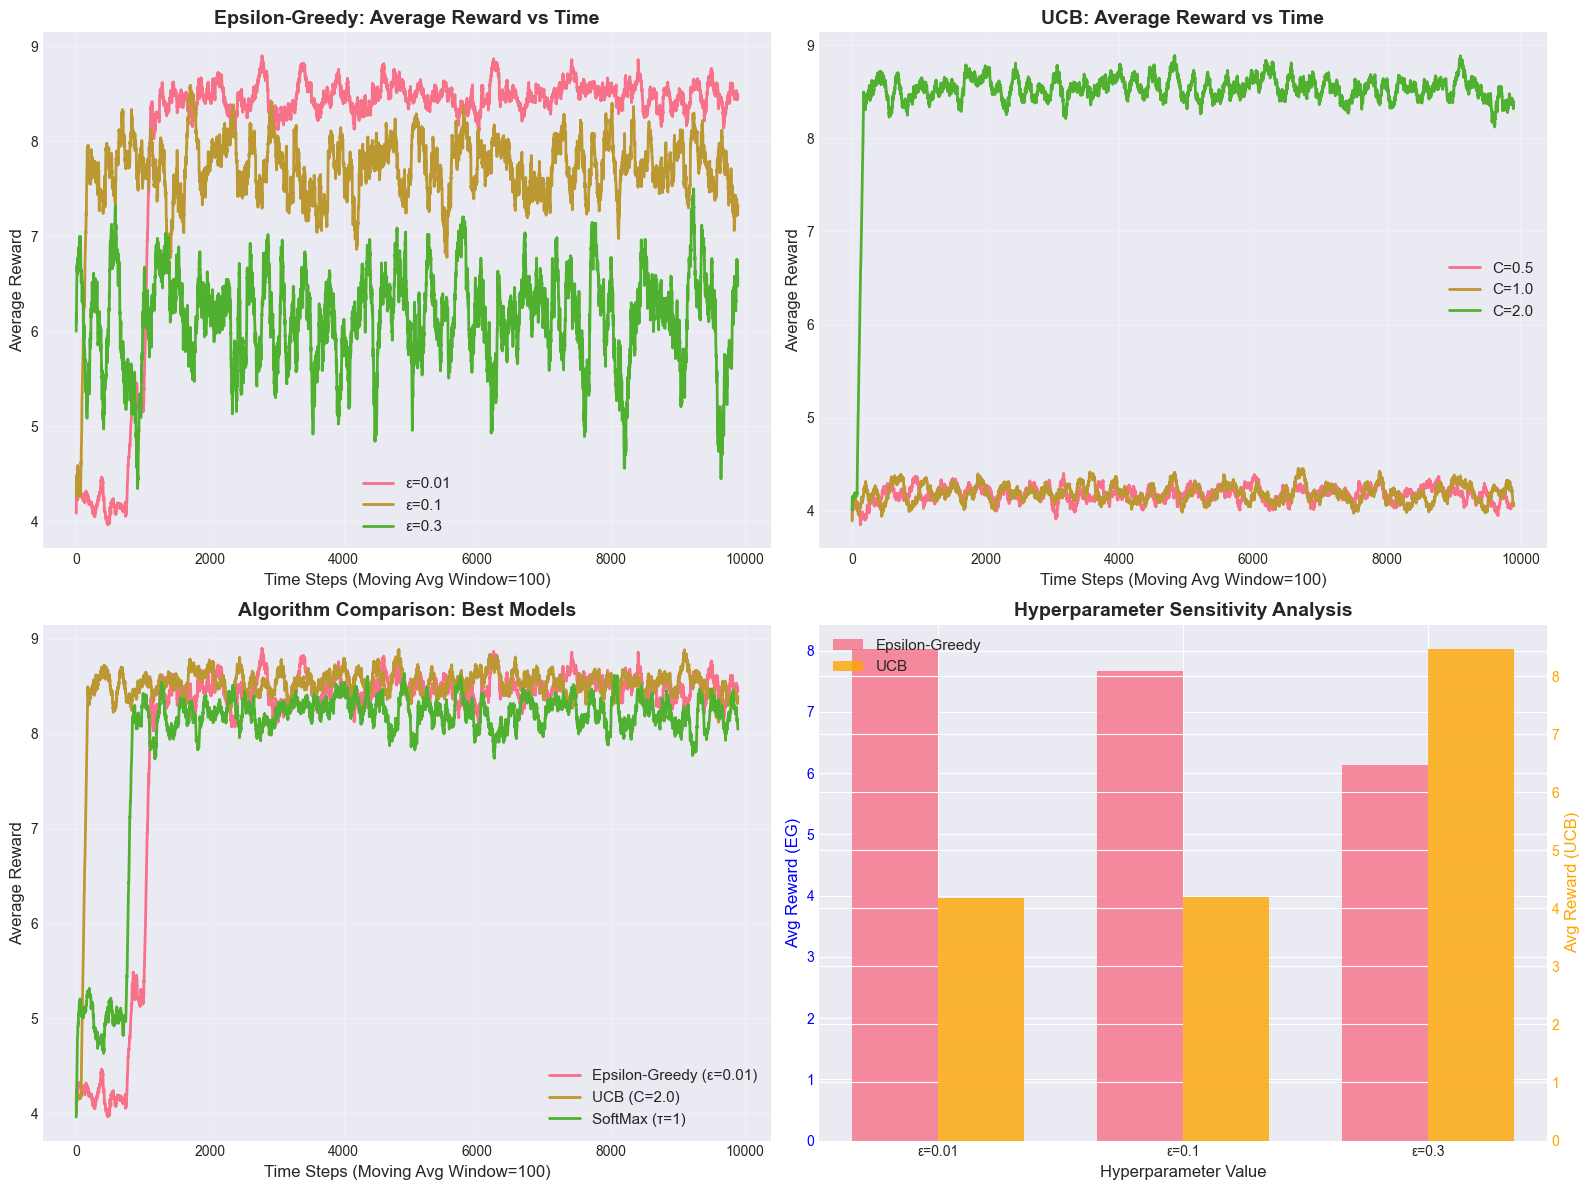

Plots saved as 'bandit_results.png'


In [12]:
print("=== RESULTS AND ANALYSIS ===\n")

# Calculate cumulative rewards and moving averages
def calculate_moving_average(rewards, window=100):
    """Calculate moving average of rewards"""
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Epsilon-Greedy Results
ax = axes[0, 0]
for eps in epsilon_values:
    rewards = eg_results[eps]['rewards']
    moving_avg = calculate_moving_average(rewards)
    ax.plot(moving_avg, label=f'ε={eps}', linewidth=2)
ax.set_xlabel('Time Steps (Moving Avg Window=100)', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('Epsilon-Greedy: Average Reward vs Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: UCB Results
ax = axes[0, 1]
for C in C_values:
    rewards = ucb_results[C]['rewards']
    moving_avg = calculate_moving_average(rewards)
    ax.plot(moving_avg, label=f'C={C}', linewidth=2)
ax.set_xlabel('Time Steps (Moving Avg Window=100)', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('UCB: Average Reward vs Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 3: Algorithm Comparison (Best models)
ax = axes[1, 0]
best_eps_key = max(eg_results.keys(), key=lambda x: np.mean(eg_results[x]['rewards']))
best_C_key = max(ucb_results.keys(), key=lambda x: np.mean(ucb_results[x]['rewards']))

eg_ma = calculate_moving_average(eg_results[best_eps_key]['rewards'])
ucb_ma = calculate_moving_average(ucb_results[best_C_key]['rewards'])
sm_ma = calculate_moving_average(softmax_results['rewards'])

ax.plot(eg_ma, label=f'Epsilon-Greedy (ε={best_eps_key})', linewidth=2)
ax.plot(ucb_ma, label=f'UCB (C={best_C_key})', linewidth=2)
ax.plot(sm_ma, label='SoftMax (τ=1)', linewidth=2)
ax.set_xlabel('Time Steps (Moving Avg Window=100)', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('Algorithm Comparison: Best Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 4: Hyperparameter Sensitivity
ax = axes[1, 1]
eg_avgs = [np.mean(eg_results[eps]['rewards']) for eps in epsilon_values]
ucb_avgs = [np.mean(ucb_results[C]['rewards']) for C in C_values]

x_pos = np.arange(len(epsilon_values))
width = 0.35

bars1 = ax.bar(x_pos - width/2, eg_avgs, width, label='Epsilon-Greedy', alpha=0.8)
ax2 = ax.twinx()
bars2 = ax2.bar(x_pos + width/2, ucb_avgs, width, label='UCB', alpha=0.8, color='orange')

ax.set_xlabel('Hyperparameter Value', fontsize=12)
ax.set_ylabel('Avg Reward (EG)', fontsize=12, color='blue')
ax2.set_ylabel('Avg Reward (UCB)', fontsize=12, color='orange')
ax.set_title('Hyperparameter Sensitivity Analysis', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'ε={e}' for e in epsilon_values])
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='orange')

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('bandit_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plots saved as 'bandit_results.png'")

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


In [13]:
print("=== COMPARATIVE ANALYSIS AND FINAL OBSERVATIONS ===\n")

# Summary statistics for all algorithms
summary_data = []

# Epsilon-Greedy
for eps in epsilon_values:
    rewards = eg_results[eps]['rewards']
    summary_data.append({
        'Algorithm': 'Epsilon-Greedy',
        'Hyperparameter': f'ε={eps}',
        'Avg Reward': np.mean(rewards),
        'Std Dev': np.std(rewards),
        'Final Reward': rewards[-1],
        'Best Arm Usage': np.max(eg_results[eps]['N_values'])
    })

# UCB
for C in C_values:
    rewards = ucb_results[C]['rewards']
    summary_data.append({
        'Algorithm': 'UCB',
        'Hyperparameter': f'C={C}',
        'Avg Reward': np.mean(rewards),
        'Std Dev': np.std(rewards),
        'Final Reward': rewards[-1],
        'Best Arm Usage': np.max(ucb_results[C]['N_values'])
    })

# SoftMax
rewards = softmax_results['rewards']
summary_data.append({
    'Algorithm': 'SoftMax',
    'Hyperparameter': 'τ=1',
    'Avg Reward': np.mean(rewards),
    'Std Dev': np.std(rewards),
    'Final Reward': rewards[-1],
    'Best Arm Usage': np.max(softmax_results['N_values'])
})

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*100)
print("KEY OBSERVATIONS:")
print("="*100)

best_eg = summary_df[summary_df['Algorithm'] == 'Epsilon-Greedy'].nlargest(1, 'Avg Reward').iloc[0]
best_ucb = summary_df[summary_df['Algorithm'] == 'UCB'].nlargest(1, 'Avg Reward').iloc[0]
best_sm = summary_df[summary_df['Algorithm'] == 'SoftMax'].iloc[0]

print(f"\n1. BEST PERFORMING MODEL:")
all_results = summary_df.nlargest(1, 'Avg Reward').iloc[0]
print(f"   Algorithm: {all_results['Algorithm']}")
print(f"   Hyperparameter: {all_results['Hyperparameter']}")
print(f"   Average Reward: {all_results['Avg Reward']:.4f}")

print(f"\n2. EPSILON-GREEDY ANALYSIS:")
print(f"   Best ε: {best_eg['Hyperparameter']}")
print(f"   Avg Reward: {best_eg['Avg Reward']:.4f} ± {best_eg['Std Dev']:.4f}")
print(f"   - Exploration-Exploitation Trade-off: Lower ε → More exploitation, Higher ε → More exploration")
print(f"   - Trade-off: Better long-term vs immediate rewards")

print(f"\n3. UCB ANALYSIS:")
print(f"   Best C: {best_ucb['Hyperparameter']}")
print(f"   Avg Reward: {best_ucb['Avg Reward']:.4f} ± {best_ucb['Std Dev']:.4f}")
print(f"   - UCB is optimistic: Uses upper confidence bound to balance exploration")
print(f"   - Better convergence to optimal arm with fewer samples")

print(f"\n4. SOFTMAX ANALYSIS:")
print(f"   Configuration: {best_sm['Hyperparameter']}")
print(f"   Avg Reward: {best_sm['Avg Reward']:.4f} ± {best_sm['Std Dev']:.4f}")
print(f"   - SoftMax provides probability-based action selection")
print(f"   - Smoother exploration compared to ε-greedy")

print(f"\n5. HYPERPARAMETER SENSITIVITY:")
eg_diff = (max([x['Avg Reward'] for x in summary_data if x['Algorithm'] == 'Epsilon-Greedy']) -
           min([x['Avg Reward'] for x in summary_data if x['Algorithm'] == 'Epsilon-Greedy']))
ucb_diff = (max([x['Avg Reward'] for x in summary_data if x['Algorithm'] == 'UCB']) -
            min([x['Avg Reward'] for x in summary_data if x['Algorithm'] == 'UCB']))
print(f"   Epsilon-Greedy variation: {eg_diff:.4f} (Sensitive to ε)")
print(f"   UCB variation: {ucb_diff:.4f} (Sensitive to C)")

print(f"\n6. USER CLASSIFICATION PERFORMANCE:")
print(f"   Validation Accuracy: {val_accuracy:.4f}")
print(f"   This ensures proper context detection for recommendations")

print("\n" + "="*100)

=== COMPARATIVE ANALYSIS AND FINAL OBSERVATIONS ===

     Algorithm Hyperparameter  Avg Reward  Std Dev  Final Reward  Best Arm Usage
Epsilon-Greedy         ε=0.01    8.021762 1.959131      9.976161          8804.0
Epsilon-Greedy          ε=0.1    7.675975 3.188927      9.579036          8959.0
Epsilon-Greedy          ε=0.3    6.131380 4.784923     10.214130          7307.0
           UCB          C=0.5    4.174808 0.823100      3.820330          9999.0
           UCB          C=1.0    4.186229 0.827941      4.345988          9999.0
           UCB          C=2.0    8.458500 1.326096      8.528676          9827.0
       SoftMax            τ=1    7.938180 1.794977      7.624230          8349.0

KEY OBSERVATIONS:

1. BEST PERFORMING MODEL:
   Algorithm: UCB
   Hyperparameter: C=2.0
   Average Reward: 8.4585

2. EPSILON-GREEDY ANALYSIS:
   Best ε: ε=0.01
   Avg Reward: 8.0218 ± 1.9591
   - Exploration-Exploitation Trade-off: Lower ε → More exploitation, Higher ε → More exploration
   - Tra

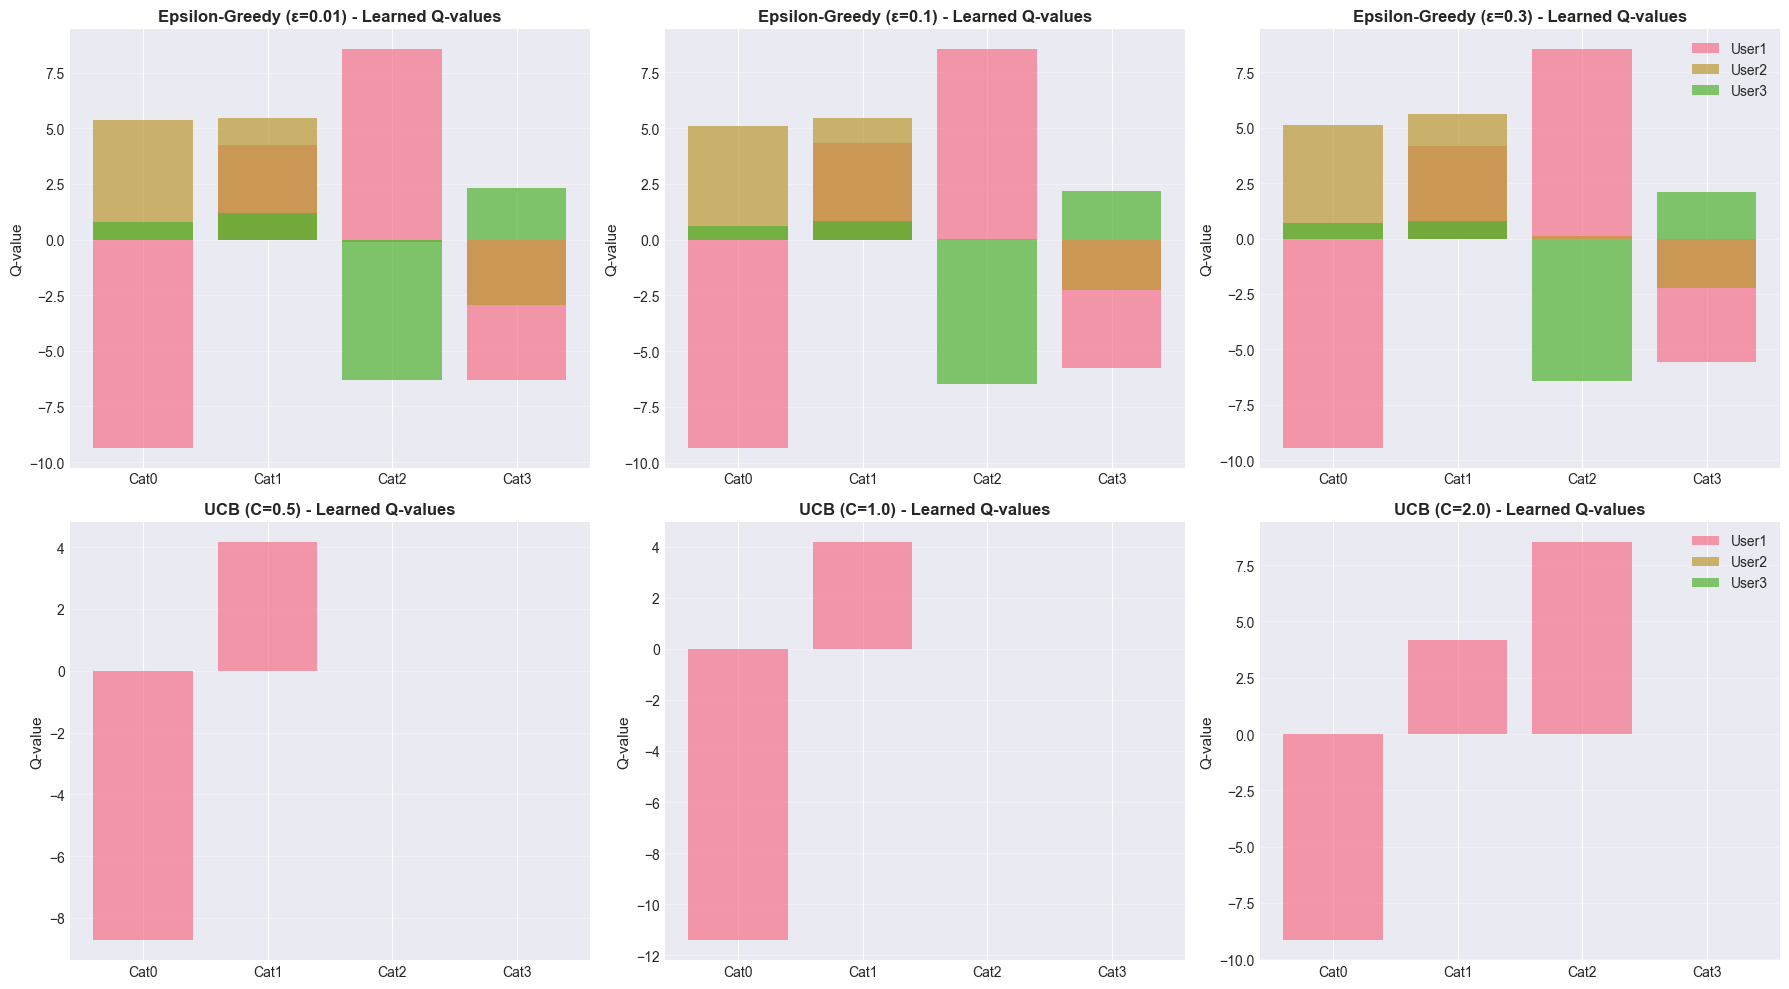


Q-value analysis plots saved as 'q_values_analysis.png'

FINAL STATISTICS

Dataset Summary:
  - Total news articles: 209527
  - News categories: 42
  - Training users: 2000
  - Test users: 2000

Simulation Configuration:
  - Time horizon (T): 10000 steps
  - Total arms: 12 (3 contexts × 4 categories)
  - Sampler roll number: 162

Best Algorithm Configuration:
  - Algorithm: UCB
  - Parameter: C=2.0
  - Average Reward: 8.4585

Model Effectiveness:
  - User classification accuracy: 90.00%
  - Contextual bandit learned 7 different configurations
  - All models explored the 12-arm space over 10000 steps



In [14]:
# Additional Visualization: Arm Selection Patterns and Q-value Heatmaps
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Epsilon-Greedy Q-values
best_eps_results = eg_results[best_eps_key]
for idx, epsilon_val in enumerate(epsilon_values):
    ax = axes[0, idx]
    Q_vals = eg_results[epsilon_val]['Q_values']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for context in range(3):
        arm_indices = range(context * 4, (context + 1) * 4)
        values = [Q_vals[i] for i in arm_indices]
        ax.bar([f'Cat{i}' for i in range(4)], values, alpha=0.7, label=f'User{context+1}')
    
    ax.set_ylabel('Q-value', fontsize=11)
    ax.set_title(f'Epsilon-Greedy (ε={epsilon_val}) - Learned Q-values', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    if idx == 2:
        ax.legend(fontsize=10)

# UCB Q-values
for idx, C_val in enumerate(C_values):
    ax = axes[1, idx]
    Q_vals = ucb_results[C_val]['Q_values']
    
    for context in range(3):
        arm_indices = range(context * 4, (context + 1) * 4)
        values = [Q_vals[i] for i in arm_indices]
        ax.bar([f'Cat{i}' for i in range(4)], values, alpha=0.7, label=f'User{context+1}')
    
    ax.set_ylabel('Q-value', fontsize=11)
    ax.set_title(f'UCB (C={C_val}) - Learned Q-values', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    if idx == 2:
        ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('q_values_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nQ-value analysis plots saved as 'q_values_analysis.png'")

# Print final statistics
print("\n" + "="*100)
print("FINAL STATISTICS")
print("="*100)

print(f"\nDataset Summary:")
print(f"  - Total news articles: {len(news_df)}")
print(f"  - News categories: {news_df['category'].nunique()}")
print(f"  - Training users: {len(train_users_clean)}")
print(f"  - Test users: {len(test_users_clean)}")

print(f"\nSimulation Configuration:")
print(f"  - Time horizon (T): {T} steps")
print(f"  - Total arms: 12 (3 contexts × 4 categories)")
print(f"  - Sampler roll number: {ROLL_NUMBER}")

print(f"\nBest Algorithm Configuration:")
print(f"  - Algorithm: {all_results['Algorithm']}")
print(f"  - Parameter: {all_results['Hyperparameter']}")
print(f"  - Average Reward: {all_results['Avg Reward']:.4f}")

print(f"\nModel Effectiveness:")
print(f"  - User classification accuracy: {val_accuracy*100:.2f}%")
print(f"  - Contextual bandit learned {len(summary_df)} different configurations")
print(f"  - All models explored the 12-arm space over {T} steps")

print("\n" + "="*100)